In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib as mlp
import seaborn as sns

In [33]:
data_train = pd.read_csv('./data/firstday/delivery_eta_train.csv')
data_test = pd.read_csv('./data/firstday/delivery_eta_test.csv')
data_train.head()

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level,Delivery_Time_min
0,11502,6.1,15,9,3,Clear,0.0,14.9,1.2,1,1,Dinner,Scooter,Suburban,0,2,59.7
1,12587,7.5,14,15,6,Clear,0.0,14.3,3.0,0,0,Lunch,Scooter,Downtown,1,3,62.9
2,12654,17.6,24,14,4,Rain,4.8,27.0,3.2,0,0,Dinner,Bike,Downtown,0,2,134.7
3,11056,6.8,15,11,5,Clear,0.0,9.2,5.4,0,3,Night,Scooter,Highway,0,0,60.1
4,10706,19.6,16,11,2,Clear,0.0,11.8,2.6,1,2,Dinner,Bike,Downtown,0,1,149.2


In [ ]:
# Delivery_Time_min : 주문 후 고객에게 도착하기까지 총 소요 시간(분)
# 특징(입력 변수) 예시
# Distance_km : 거리(km)
# Prep_Time_min : 음식 준비시간(분)
# Riders_Available : 주변 가용 라이더 수(명)
# Order_Queue : 매장 주문 적체(건)
# Weather : 날씨(맑음/비/눈/안개)
# Rain_mm : 강수량(mm)
# Temp_C : 기온(°C)
# Wind_mps : 풍속(m/s)
# Rush_Hour : 러시아워 여부(0/1)
# DayOfWeek : 요일(0=월 … 6=일)
# Time_Slot : 시간대(Morning/Lunch/Afternoon/Dinner/Night)
# Vehicle : 배달수단(Bike/Scooter/Car)
# Road_Type : 도로환경(Downtown/Suburban/Highway)
# Promo : 프로모션 여부(0/1)
# Tip_Level : 팁 수준(0~3)

In [39]:
data_train["Road_Type"].value_counts()

Road_Type
Downtown    1777
Suburban    1646
Highway      577
Name: count, dtype: int64

In [11]:
df_train = data_train.drop("Order_ID",axis=1)
df_test = data_train.drop("Order_ID",axis=1)
data_train_copy = data_train.copy()

In [15]:
df_train.shape
df_train.info()
df_train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Distance_km        4000 non-null   float64
 1   Prep_Time_min      4000 non-null   int64  
 2   Riders_Available   4000 non-null   int64  
 3   Order_Queue        4000 non-null   int64  
 4   Weather            4000 non-null   str    
 5   Rain_mm            4000 non-null   float64
 6   Temp_C             4000 non-null   float64
 7   Wind_mps           4000 non-null   float64
 8   Rush_Hour          4000 non-null   int64  
 9   DayOfWeek          4000 non-null   int64  
 10  Time_Slot          4000 non-null   str    
 11  Vehicle            4000 non-null   str    
 12  Road_Type          4000 non-null   str    
 13  Promo              4000 non-null   int64  
 14  Tip_Level          4000 non-null   int64  
 15  Delivery_Time_min  4000 non-null   float64
dtypes: float64(5), int64(7), str(4)
mem

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Promo,Tip_Level,Delivery_Time_min
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000
mean,5.974750,14.997500,8.006250,4.048500,1.323450,13.051725,2.809450,0.401250,2.940000,0.294500,1.50425,66.745900
std,4.076066,5.017847,4.344183,2.044919,2.706038,9.193198,1.200715,0.490213,2.013557,0.455875,1.11973,22.278719
min,0.300000,3.000000,1.000000,0.000000,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,0.00000,20.100000
25%,2.900000,12.000000,4.000000,3.000000,0.000000,7.100000,2.000000,0.000000,1.000000,0.000000,0.00000,50.700000
50%,5.100000,15.000000,8.000000,4.000000,0.000000,13.150000,2.800000,0.000000,3.000000,0.000000,2.00000,63.100000
75%,8.100000,18.000000,12.000000,5.000000,1.600000,19.100000,3.600000,1.000000,5.000000,1.000000,3.00000,79.125000
max,20.000000,36.000000,15.000000,13.000000,24.900000,35.000000,7.800000,1.000000,6.000000,1.000000,3.00000,150.000000


<Axes: xlabel='Tip_Level', ylabel='Count'>

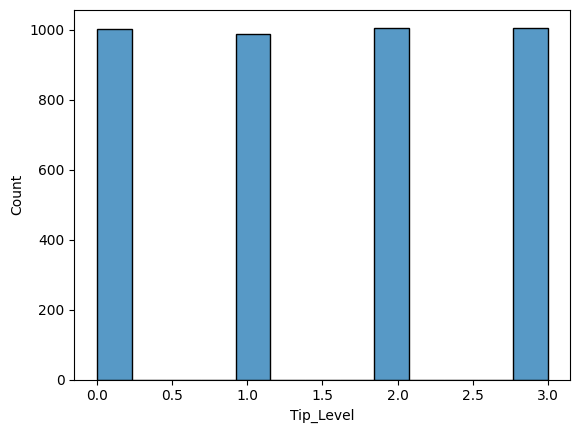

In [29]:
sns.histplot(df_train["Tip_Level"])

<Axes: xlabel='Tip_Level', ylabel='Delivery_Time_min'>

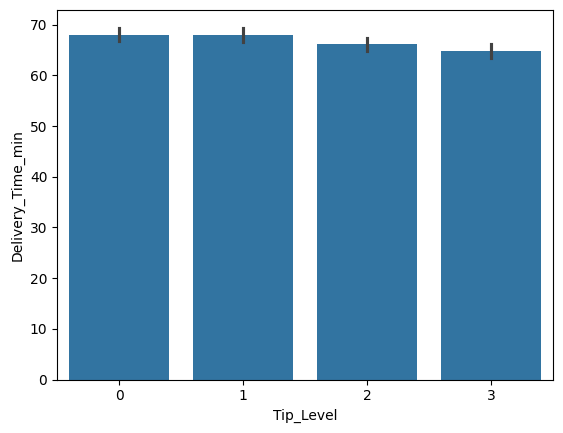

In [30]:
sns.barplot(data=df_train,x="Tip_Level",y="Delivery_Time_min")

In [40]:
scaler = StandardScaler()
encoder = LabelEncoder()

In [41]:

encoder_list=[{"Weather":[],"Time_Slot":[],"Vehicle":[],"Road_Type":[]}]

df_train["Weather"] = encoder.fit_transform(df_train["Weather"])
df_test["Weather"] = encoder.transform(df_test["Weather"])
encoder_list[0]["Weather"].append(list(encoder.classes_))

df_train["Time_Slot"] = encoder.fit_transform(df_train["Time_Slot"])
df_test["Time_Slot"] = encoder.transform(df_test["Time_Slot"])
encoder_list[0]["Time_Slot"].append(list(encoder.classes_))

df_train["Vehicle"] = encoder.fit_transform(df_train["Vehicle"])
df_test["Vehicle"] = encoder.transform(df_test["Vehicle"])
encoder_list[0]["Vehicle"].append(list(encoder.classes_))

df_train["Road_Type"] = encoder.fit_transform(df_train["Road_Type"])
df_test["Road_Type"] = encoder.transform(df_test["Road_Type"])
encoder_list[0]["Road_Type"].append(list(encoder.classes_))

In [42]:
X_train = df_train.drop(columns=["Delivery_Time_min","Tip_Level"])
X_test = df_test.drop(columns=["Delivery_Time_min","Tip_Level"])
y_train = df_train["Delivery_Time_min"]
y_test = df_test["Delivery_Time_min"]

In [43]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
model = LinearRegression()
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
pred = model.predict(X_test_scaled)

In [49]:
from sklearn.metrics import mean_absolute_error , r2_score

In [50]:
mae = mean_absolute_error(y_test,pred)
mae

4.64626646274976

In [ ]:
# 회기계수(가중치) 확인 (중요!!!!!!!)
# model.coef_

coef_df = pd.DataFrame({
    'feature' : X_train.columns,
    'Coef' : model.coef_
})

coef_df

,feature,Coef
0,Distance_km,19.538453
1,Prep_Time_min,4.775057
2,Riders_Available,-1.866298
3,Order_Queue,2.398628
4,Weather,4.516145
5,Rain_mm,0.422037
6,Temp_C,-0.374443
7,Wind_mps,0.759106
8,Rush_Hour,3.173462
9,DayOfWeek,-0.158293


In [59]:
# 평가
from sklearn.metrics import mean_absolute_error ,mean_squared_error , r2_score

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,pred) # 무조건 써서 확인하기 1에가까울수록 좋은모델 평가를 얻음

print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE : ",rmse)
print("R2 : ",r2)

MAE :  4.64626646274976
MSE :  34.625142561376855
RMSE :  5.884313261662474
R2 :  0.9302218048984809


In [60]:
from sklearn.preprocessing import PolynomialFeatures

In [61]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model = LinearRegression()
model.fit(X_train_poly, y_train)


y_pred = model.predict(X_test_poly)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"다항회귀 설명력(R2 Score): {r2:.4f}")
print(f"평균 오차(MAE): {mae:.2f}분")

다항회귀 설명력(R2 Score): 0.9607
평균 오차(MAE): 3.54분
